In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import joblib

In [3]:
customers = pd.read_csv("../data/processed/customers.csv")
transactions = pd.read_csv("../data/processed/cleaned_data.csv")

transactions["InvoiceDate"] = pd.to_datetime(transactions["InvoiceDate"])
customers["LastPurchaseDate"] = pd.to_datetime(customers["LastPurchaseDate"])


In [4]:
# Drop missing values if needed
customers = customers.dropna()
transactions = transactions.dropna()

In [7]:
# Create churn target (no data leakage)

# Define cutoff date (80% of timeline)
cutoff_date = transactions["InvoiceDate"].quantile(0.80)

# Get customers who purchased AFTER cutoff date
future_purchases = transactions[transactions["InvoiceDate"] > cutoff_date]

active_customers = future_purchases["CustomerID"].unique()

# Create churn target
customers["churn"] = ~customers["CustomerID"].isin(active_customers)
customers["churn"] = customers["churn"].astype(int)

# Display churn distribution
print("Churn distribution:")
print(customers["churn"].value_counts(normalize=True))

Churn distribution:
churn
1    0.565929
0    0.434071
Name: proportion, dtype: float64


In [8]:
# Feature engineering (RFM version - simplified)

historical_transactions = transactions[transactions["InvoiceDate"] <= cutoff_date].copy()

customer_features = historical_transactions.groupby("CustomerID").agg(
    number_of_orders=("InvoiceNo", "nunique"),     # Frequency
    total_revenue=("TotalPrice", "sum"),           # Monetary
    last_purchase_date=("InvoiceDate", "max")
).reset_index()

# Recency
customer_features["recency_before_cutoff"] = (
    cutoff_date - customer_features["last_purchase_date"]
).dt.days

# Drop date column
customer_features = customer_features.drop(columns=["last_purchase_date"])

customer_features.head()

,CustomerID,number_of_orders,total_revenue,recency_before_cutoff
0,12346.0,1,77183.60,287
1,12347.0,6,4085.18,1
2,12348.0,4,1797.24,37
3,12350.0,1,334.40,271
4,12352.0,7,2194.31,34


In [9]:
# Merge customer table with engineered RFM features
# We merge the churn target with customer-level features created from historical transactions.

df = customers[["CustomerID", "churn"]].merge(
    customer_features,
    on="CustomerID",
    how="left"
)

# Fill missing values
# Missing values mean that a customer had no transaction before the cutoff date.

df = df.fillna({
    "number_of_orders": 0,
    "total_revenue": 0,
    "recency_before_cutoff": 999
})

# Display first rows
df.head()

,CustomerID,churn,number_of_orders,total_revenue,recency_before_cutoff
0,12346.0,1,1.0,77183.60,287.0
1,12347.0,0,6.0,4085.18,1.0
2,12348.0,1,4.0,1797.24,37.0
3,12349.0,0,0.0,0.00,999.0
4,12350.0,1,1.0,334.40,271.0


In [10]:
# Select model features (RFM simplified)

features = [
    "number_of_orders",        # Frequency
    "total_revenue",           # Monetary
    "recency_before_cutoff"    # Recency
]

target = "churn"

X = df[features]
y = df[target]

In [13]:
# Preprocessing for RFM numerical features

# All selected features are numerical, so we only apply StandardScaler.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), features)
    ]
)

In [14]:
# Train / test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")

Train size: (3470, 3)
Test size: (868, 3)


In [15]:
# Model 1: Logistic Regression (baseline)

log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

# Train the model
log_model.fit(X_train, y_train)

# Make predictions
y_pred_log = log_model.predict(X_test)

# Predict probabilities
y_proba_log = log_model.predict_proba(X_test)[:, 1]

# Evaluate the model
print("===== LOGISTIC REGRESSION =====")
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))
print("ROC AUC:", roc_auc_score(y_test, y_proba_log))

===== LOGISTIC REGRESSION =====
[[207 170]
 [ 87 404]]
              precision    recall  f1-score   support

           0       0.70      0.55      0.62       377
           1       0.70      0.82      0.76       491

    accuracy                           0.70       868
   macro avg       0.70      0.69      0.69       868
weighted avg       0.70      0.70      0.70       868

ROC AUC: 0.7257640175682173


In [16]:
# Model 2: Random Forest
# -----------------------------
# Random Forest is a powerful ensemble model that combines multiple decision trees.
# It can capture non-linear relationships and usually performs better on tabular data.

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced",
        max_depth=8,
        min_samples_split=10
    ))
])

# Train the model
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Probabilities for ROC AUC
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluation
print("===== RANDOM FOREST =====")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_proba_rf))
print()

===== RANDOM FOREST =====
[[235 142]
 [111 380]]
              precision    recall  f1-score   support

           0       0.68      0.62      0.65       377
           1       0.73      0.77      0.75       491

    accuracy                           0.71       868
   macro avg       0.70      0.70      0.70       868
weighted avg       0.71      0.71      0.71       868

ROC AUC: 0.7600712020615104



In [19]:
# -----------------------------
# 10. Model 3: XGBoost
# -----------------------------
# XGBoost is a gradient boosting algorithm that often performs very well
# on structured/tabular datasets.
# We also evaluate a custom threshold to prioritize churn detection.

from xgboost import XGBClassifier

xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    ))
])

# Train the model
xgb_model.fit(X_train, y_train)

# Predict class labels using the default threshold = 0.5
y_pred_xgb = xgb_model.predict(X_test)

# Predict churn probabilities
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Evaluate model with default threshold
print("===== XGBOOST (default threshold = 0.5) =====")
print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))
print("ROC AUC:", roc_auc_score(y_test, y_proba_xgb))
print()

# -----------------------------
# Custom business threshold
# -----------------------------
# A lower threshold helps detect more churn customers.
# This usually increases recall but may reduce precision.

threshold = 0.4

y_pred_xgb_custom = (y_proba_xgb >= threshold).astype(int)

print(f"===== XGBOOST (custom threshold = {threshold}) =====")
print(confusion_matrix(y_test, y_pred_xgb_custom))
print(classification_report(y_test, y_pred_xgb_custom))
print()

===== XGBOOST (default threshold = 0.5) =====
[[204 173]
 [ 90 401]]
              precision    recall  f1-score   support

           0       0.69      0.54      0.61       377
           1       0.70      0.82      0.75       491

    accuracy                           0.70       868
   macro avg       0.70      0.68      0.68       868
weighted avg       0.70      0.70      0.69       868

ROC AUC: 0.7505118661098716

===== XGBOOST (custom threshold = 0.4) =====
[[176 201]
 [ 46 445]]
              precision    recall  f1-score   support

           0       0.79      0.47      0.59       377
           1       0.69      0.91      0.78       491

    accuracy                           0.72       868
   macro avg       0.74      0.69      0.69       868
weighted avg       0.73      0.72      0.70       868




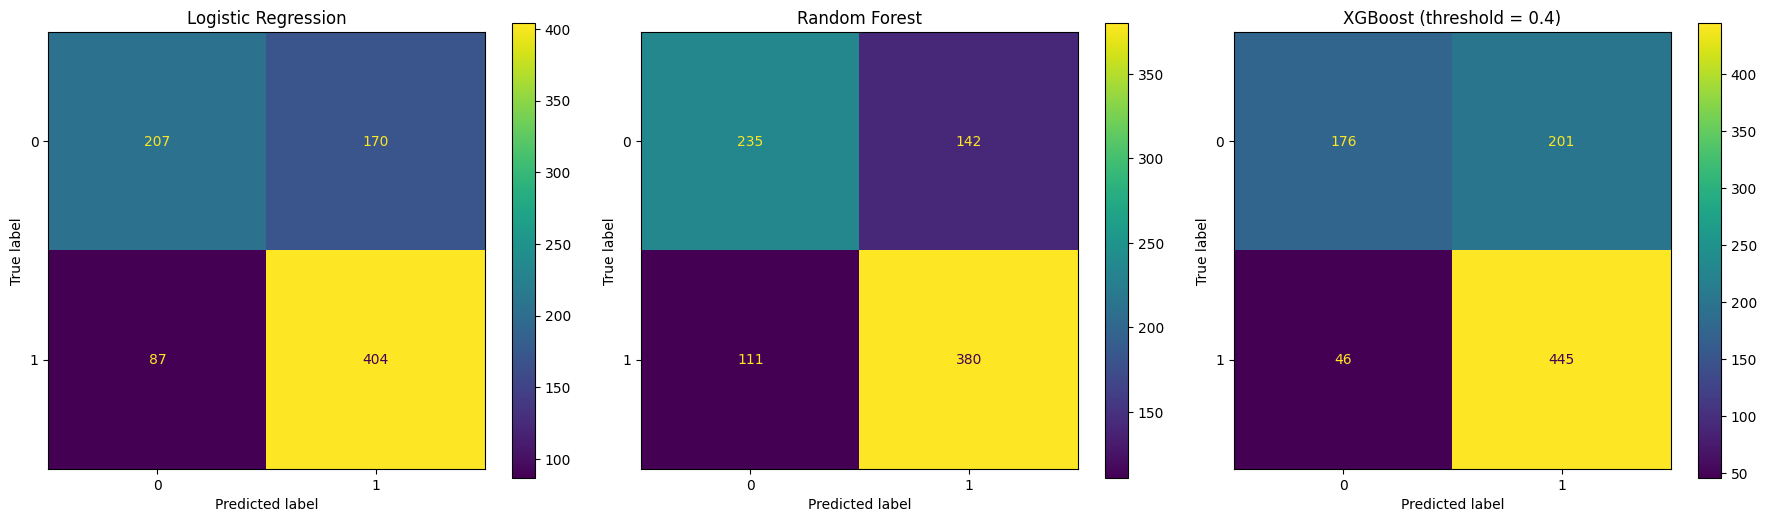

In [22]:
# Compare models

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Logistic Regression
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_log,
    ax=axes[0]
)
axes[0].set_title("Logistic Regression")

# Random Forest
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    ax=axes[1]
)
axes[1].set_title("Random Forest")

# XGBoost (custom threshold)
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb_custom,
    ax=axes[2]
)
axes[2].set_title("XGBoost (threshold = 0.4)")

plt.tight_layout()
plt.show()

In [23]:
import os
import joblib

# Create models folder at project root
os.makedirs("../models", exist_ok=True)

# Save model
joblib.dump({
    "model": xgb_model,
    "threshold": 0.4
}, "../models/churn_model.pkl")

print("Model saved in ../models/")

Model saved in ../models/
